# FC Box Plots: Models x Conditions x Regions

2x2 grid of box plots (one per brain region) comparing FC across 3 pharmacological conditions and 6 models (5 trained + empirical).

In [1]:
import os
import sys
from pathlib import Path

notebook_dir = Path().absolute()
if notebook_dir.name == 'examples':
    os.chdir(notebook_dir.parent)

import torch
import numpy as np
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

## Configuration

In [2]:
LSD_DATA_DIR   = "data/lsd"
CHECKPOINT_DIR = "checkpoints"
DATASET_TYPE   = "lsd"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
N_STEPS        = 240          # simulation length (match empirical timepoints)
GROUP_SIZE     = 0            # 0 = per-subject FC

ROI_NAMES = ["Thalamus", "Visual Cortex", "PCC", "Temporal Gyrus"]

# Conditions are encoded as 2-D control vectors (LSD, Ketanserin):
#   Placebo        -> (0, 0)
#   LSD            -> (1, 0)
#   LSD+Ketanserin -> (0, 1)
CONDITION_LABELS = {
    (0, 0): "Placebo",
    (1, 0): "LSD",
    (0, 1): "LSD+Ketanserin",
}
CONDITION_COLORS = {
    (0, 0): "#4878CF",
    (1, 0): "#6ACC65",
    (0, 1): "#D65F5F",
}

print(f"Device: {DEVICE}")

Device: cpu


## 1. Load Dataset

In [3]:
from src.dataset import NeuroscienceDataset
from src.metrics import compute_static_fc, fisher_batch_average
from src.training.evaluation import rollout_model

dataset = NeuroscienceDataset.from_lsd(data_dir=LSD_DATA_DIR, normalize=True, device=DEVICE)
print(f"n_rois={dataset.n_rois}  n_subjects={dataset.n_subjects}  T={dataset.n_timepoints}")

# Group subject indices by full control vector (handles LSD's 2-D one-hot pairs).
subjects_per_ctrl = {}
ctrl_np = dataset.control.detach().cpu().numpy()
for cv in CONDITION_LABELS.keys():
    target = np.asarray(cv, dtype=ctrl_np.dtype)
    if ctrl_np.shape[1] != target.shape[0]:
        raise RuntimeError(
            f"Control dim mismatch: dataset has {ctrl_np.shape[1]} dims, "
            f"CONDITION_LABELS expects {target.shape[0]}"
        )
    mask = np.all(ctrl_np == target, axis=1)
    if mask.sum() > 0:
        idx = torch.from_numpy(np.nonzero(mask)[0]).to(dataset.timeseries.device)
        subjects_per_ctrl[cv] = idx
        print(f"  ctrl={cv} ({CONDITION_LABELS[cv]}): {int(mask.sum())} subjects")

LSD dataset: conditions=['Placebo', 'LSD', 'LSD+Ketanserin'], control_vectors=[(0.0, 0.0), (0.0, 1.0), (1.0, 0.0)], n_patients=25, n_timeseries=75
n_rois=4  n_subjects=75  T=240
  ctrl=(0, 0) (Placebo): 25 subjects
  ctrl=(1, 0) (LSD): 25 subjects
  ctrl=(0, 1) (LSD+Ketanserin): 25 subjects


## 2. Load Checkpoints

In [4]:
from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ("gnn_hopf",      "GNN Hopf"),
    ("hybrid_neural", "Hybrid+Neural"),
    ("hybrid_hopf",   "Hybrid Hopf"),
    ("nsde",          "Neural SDE"),
    ("hopf",          "Hopf"),
]

def _short_label(stem):
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (" (Grid)" if "grid" in lower else "")
    return stem

ckpt_dir = Path(CHECKPOINT_DIR)
checkpoint_paths = sorted(ckpt_dir.glob(f"*{DATASET_TYPE}*.pt"))
print(f"Found {len(checkpoint_paths)} checkpoints")

models = {}
for p in checkpoint_paths:
    try:
        model, mtype, _ = load_model_from_checkpoint(str(p), device=DEVICE)
        if model.n_rois != dataset.n_rois:
            print(f"  Skip {p.name}: ROI mismatch")
            continue
        label = _short_label(p.stem)
        models[label] = model
        print(f"  Loaded '{label}' ({mtype})")
    except Exception as exc:
        print(f"  Failed {p.name}: {exc}")

print(f"\n{len(models)} model(s): {list(models.keys())}")

Found 6 checkpoints
  Loaded 'GNN Hopf' (GNNHopfModel)
  Loaded 'Hopf' (CoupledHopfModel)
  Loaded 'Hopf (Grid)' (CoupledHopfModel)
  Loaded 'Hybrid Hopf' (HybridHopfModel)
  Loaded 'Hybrid+Neural' (HybridHopfNeuralModel)
  Loaded 'Neural SDE' (NeuralSDE)

6 model(s): ['GNN Hopf', 'Hopf', 'Hopf (Grid)', 'Hybrid Hopf', 'Hybrid+Neural', 'Neural SDE']


## 3. Compute Per-Subject FC for Each Model and Condition\n\nFor each condition we select the corresponding subjects, simulate (or use empirical timeseries), and compute per-subject FC matrices. We then extract the mean connectivity of each ROI (mean of its row, excluding diagonal).

In [5]:
n_rois = dataset.n_rois
sim_steps = min(N_STEPS, dataset.n_timepoints)

# --- Simulation cache (per-model, per-condition) -----------------------------
PRED_CACHE_DIR = Path("cache/predictions") / DATASET_TYPE / "fc_boxplots"
PRED_CACHE_DIR.mkdir(parents=True, exist_ok=True)
FORCE_RECOMPUTE_PREDS = False

def _safe(name):
    return "".join(c if c.isalnum() else "_" for c in name).strip("_")

def _ctrl_tag(cv):
    if isinstance(cv, tuple):
        return "ctrl_" + "_".join(str(int(v)) for v in cv)
    return f"ctrl{cv}"

def _sim_cache_path(model_name, cv):
    return PRED_CACHE_DIR / f"{_safe(model_name)}_{_ctrl_tag(cv)}_T{sim_steps}.pt"

def mean_fc_per_roi(fc_matrices):
    """Per-subject mean FC for each ROI (mean of row, excluding diagonal).

    Args:
        fc_matrices: (n_subjects, n_rois, n_rois) tensor
    Returns:
        (n_subjects, n_rois) numpy array
    """
    fc = fc_matrices.detach().cpu().numpy()
    if np.iscomplexobj(fc):
        fc = fc.real
    mask = ~np.eye(fc.shape[-1], dtype=bool)
    result = np.zeros((fc.shape[0], fc.shape[1]))
    for i in range(fc.shape[1]):
        result[:, i] = fc[:, i, mask[i]].mean(axis=-1)
    return result

# Collect data: fc_data[model_name][condition] = (n_subjects, n_rois)
fc_data = {}
ts_sim = {}  # ts_sim[model_name][condition] = (n_subjects, n_rois, T) tensor (cpu)

# --- Empirical ---
fc_data["Empirical"] = {}
ts_sim["Empirical"] = {}
for cv, idx in subjects_per_ctrl.items():
    emp_ts = dataset.timeseries[idx, :, :sim_steps]
    emp_fc = compute_static_fc(emp_ts)  # (n_subj, n_rois, n_rois)
    fc_data["Empirical"][cv] = mean_fc_per_roi(emp_fc)
    ts_sim["Empirical"][cv] = emp_ts.detach().cpu()
    print(f"  Empirical ctrl={cv}: {emp_fc.shape[0]} subjects")

# --- Trained models ---
for mname, model in models.items():
    fc_data[mname] = {}
    ts_sim[mname] = {}
    for cv, idx in subjects_per_ctrl.items():
        cache_path = _sim_cache_path(mname, cv)
        if cache_path.exists() and not FORCE_RECOMPUTE_PREDS:
            simulated = torch.load(cache_path, map_location=DEVICE)
            print(f"  Loaded cached '{mname}' ctrl={cv} from {cache_path}")
        else:
            target_ts = dataset.timeseries[idx, :, :sim_steps]
            initial_state = target_ts[:, :, 0]

            n_ctrl = getattr(model, "n_control_dims", 0)
            ctrl = None
            if n_ctrl > 0:
                # Use the dataset's actual control vectors for these subjects
                # (handles multi-dim control like LSD's (placebo, lsd, ket) one-hot pairs).
                ctrl = dataset.control[idx].to(DEVICE).float()
                if ctrl.dim() == 1:
                    ctrl = ctrl.unsqueeze(-1)
                if ctrl.shape[-1] != n_ctrl:
                    raise RuntimeError(
                        f"Control dim mismatch for '{mname}': model expects {n_ctrl}, "
                        f"dataset.control has {ctrl.shape[-1]}"
                    )

            with torch.no_grad():
                simulated = rollout_model(model, initial_state, sim_steps, dataset.dt, control=ctrl)
            torch.save(simulated.detach().cpu(), cache_path)
            print(f"  Computed '{mname}' ctrl={cv} -> {cache_path}")

        fc_pred = compute_static_fc(simulated)  # (n_subj, n_rois, n_rois)
        fc_data[mname][cv] = mean_fc_per_roi(fc_pred)
        ts_sim[mname][cv] = simulated.detach().cpu()

model_names = list(fc_data.keys())
print(f"\nModels: {model_names}")

  Empirical ctrl=(0, 0): 25 subjects
  Empirical ctrl=(1, 0): 25 subjects
  Empirical ctrl=(0, 1): 25 subjects
  Loaded cached 'GNN Hopf' ctrl=(0, 0) from cache/predictions/lsd/fc_boxplots/GNN_Hopf_ctrl_0_0_T240.pt
  Loaded cached 'GNN Hopf' ctrl=(1, 0) from cache/predictions/lsd/fc_boxplots/GNN_Hopf_ctrl_1_0_T240.pt
  Loaded cached 'GNN Hopf' ctrl=(0, 1) from cache/predictions/lsd/fc_boxplots/GNN_Hopf_ctrl_0_1_T240.pt
  Loaded cached 'Hopf' ctrl=(0, 0) from cache/predictions/lsd/fc_boxplots/Hopf_ctrl_0_0_T240.pt
  Loaded cached 'Hopf' ctrl=(1, 0) from cache/predictions/lsd/fc_boxplots/Hopf_ctrl_1_0_T240.pt
  Loaded cached 'Hopf' ctrl=(0, 1) from cache/predictions/lsd/fc_boxplots/Hopf_ctrl_0_1_T240.pt
  Loaded cached 'Hopf (Grid)' ctrl=(0, 0) from cache/predictions/lsd/fc_boxplots/Hopf__Grid_ctrl_0_0_T240.pt
  Loaded cached 'Hopf (Grid)' ctrl=(1, 0) from cache/predictions/lsd/fc_boxplots/Hopf__Grid_ctrl_1_0_T240.pt
  Loaded cached 'Hopf (Grid)' ctrl=(0, 1) from cache/predictions/lsd/fc

## 4. Box Plots: 2x2 Grid (one per region)

In [6]:
model_names = ['Empirical',
 'GNN Hopf',
 'Hopf',
 'Hopf (Grid)',
 'Hybrid Hopf',
 'Hybrid+Neural',
 'Neural SDE']

In [7]:
model_names = ['Empirical',
 'Hopf',
 'Neural SDE',
 'GNN Hopf',]

model_names = ['Empirical',
 'Hopf',
 'Neural SDE',
 'GNN Hopf',]

model_names2 = ['Empirical',
 'Hopf',
 'Neural SDE',
 'Hybrid',]

In [8]:
ctrl_vals = sorted(CONDITION_LABELS.keys())
n_models = len(model_names)
n_conds = len(ctrl_vals)

# Box positions: group by model, sub-group by condition
box_width = 0.25
group_width = n_conds * box_width + 0.15  # spacing between model groups

fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

for roi_idx in range(n_rois):
    ax = axes[roi_idx]
    all_bp = []

    for mi, mname in enumerate(model_names):
        group_center = mi * group_width
        for ci, cv in enumerate(ctrl_vals):
            data = fc_data[mname].get(cv)
            if data is None:
                continue
            values = data[:, roi_idx]
            pos = group_center + (ci - 1) * box_width
            color = CONDITION_COLORS[cv]

            bp = ax.boxplot(
                values, positions=[pos], widths=box_width * 0.8,
                patch_artist=True, manage_ticks=False,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color="gray"),
                capprops=dict(color="gray"),
                flierprops=dict(marker="o", markersize=3, alpha=0.5),
            )
            all_bp.append(bp)

    # X-axis: model names at group centers
    ax.set_xticks([mi * group_width for mi in range(n_models)])
    if roi_idx>1: 
        ax.set_xticklabels(model_names2, rotation=25, ha="right", fontsize=9)
    else:
        ax.set_xticklabels([])
    if roi_idx%2==0: ax.set_ylabel("Mean FC", fontsize=10)
    ax.set_title(ROI_NAMES[roi_idx], fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Shared legend
legend_patches = [
    mpatches.Patch(facecolor=CONDITION_COLORS[cv], alpha=0.7, label=CONDITION_LABELS[cv])
    for cv in ctrl_vals
]
fig.legend(handles=legend_patches, loc="upper center", ncol=n_conds, fontsize=11,
           bbox_to_anchor=(0.5, 1.0), frameon=True)

fig.suptitle("FC by Region, Model, and Condition", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("paper/images/lsd/fc_boxplots_by_region.pdf", bbox_inches="tight", dpi=150)
from pathlib import Path
Path("paper/images_png/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_png/lsd/fc_boxplots_by_region.png", bbox_inches="tight", dpi=200)
Path("paper/images_svg/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_svg/lsd/fc_boxplots_by_region.svg", bbox_inches="tight")
plt.show()

In [17]:
%matplotlib inline

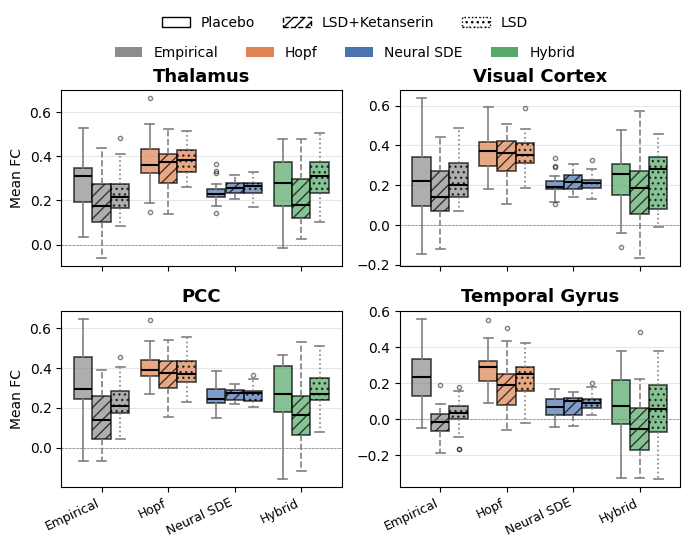

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# 1. Map Colors to Models
# Adding a neutral gray for Empirical and covering both 'GNN Hopf' and 'Hybrid' keys
FC_MODEL_COLORS = {
    "Empirical": "#8C8C8C",   # gray (baseline/target)
    "Hopf": "#DD8452",        # salmon
    "Neural SDE": "#4C72B0",  # blue
    "GNN Hopf": "#55A868",    # green
    "Hybrid": "#55A868",      # green
}

# 2. Map Shapes/Patterns to Conditions
# Assuming 3 conditions based on your positioning logic. 
# We'll use hatch patterns (solid, striped, dotted) and box edge line styles.
CONDITION_HATCHES = {
    ctrl_vals[0]: "",      # Plain (solid fill)
    ctrl_vals[1]: "///",   # Dashed/Slanted stripes
    ctrl_vals[2]: "...",   # Dotted pattern
}

CONDITION_LINESTYLES = {
    ctrl_vals[0]: "-",     # Plain line
    ctrl_vals[1]: "--",    # Dashed line
    ctrl_vals[2]: ":",     # Dotted line
}

model_names = ['Empirical', 'Hopf', 'Neural SDE', 'GNN Hopf']
model_names2 = ['Empirical', 'Hopf', 'Neural SDE', 'Hybrid']

ctrl_vals = sorted(CONDITION_LABELS.keys())
n_models = len(model_names)
n_conds = len(ctrl_vals)

# Box positions: group by model, sub-group by condition
box_width = 0.25
group_width = n_conds * box_width + 0.15  # spacing between model groups

fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

for roi_idx in range(n_rois):
    ax = axes[roi_idx]
    all_bp = []

    for mi, mname in enumerate(model_names):
        group_center = mi * group_width
        
        # Color is now based on the MODEL
        model_color = FC_MODEL_COLORS[mname] 
        
        for ci, cv in enumerate(ctrl_vals):
            data = fc_data[mname].get(cv)
            if data is None:
                continue
            values = data[:, roi_idx]
            
            # (ci - 1) centers a 3-condition group. 
            # If n_conds is not 3, use: pos = group_center + (ci - (n_conds-1)/2) * box_width
            pos = group_center + (ci - 1) * box_width

            bp = ax.boxplot(
                values, positions=[pos], widths=box_width * 0.99,
                patch_artist=True, manage_ticks=False,
                boxprops=dict(
                    facecolor=model_color, 
                    alpha=0.7,
                    edgecolor="black",         # Black edges so patterns pop
                    linestyle=CONDITION_LINESTYLES[cv], 
                    linewidth=1.2,
                    hatch=CONDITION_HATCHES[cv] # Apply shape/pattern
                ),
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color="gray", linestyle=CONDITION_LINESTYLES[cv], linewidth=1.2),
                capprops=dict(color="gray", linewidth=1.2),
                flierprops=dict(marker="o", markersize=3, alpha=0.5),
            )
            all_bp.append(bp)

    # X-axis: model names at group centers
    ax.set_xticks([mi * group_width for mi in range(n_models)])
    if roi_idx > 1: 
        ax.set_xticklabels(model_names2, rotation=25, ha="right", fontsize=9)
    else:
        ax.set_xticklabels([])

        
    if roi_idx % 2 == 0: 
        ax.set_ylabel("Mean FC", fontsize=10)
        
    ax.set_title(ROI_NAMES[roi_idx], fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")


# 3. Create Legends
# Legend A: Models (Colors)
model_patches = [
    mpatches.Patch(facecolor=FC_MODEL_COLORS[m], alpha=1.0, label=m)
    for m in model_names2
]

# Legend B: Conditions (Shapes/Patterns)
# We use white facecolor here so the pattern is clear in the legend
cond_patches = [
    mpatches.Patch(
        facecolor="white", edgecolor="black", alpha=1.0,
        hatch=CONDITION_HATCHES[cv], linestyle=CONDITION_LINESTYLES[cv], 
        label=CONDITION_LABELS[cv]
    )
    for cv in ctrl_vals
]

# Add both legends to the top
# Shifted slightly up so they stack nicely without overlapping the title
fig.legend(handles=cond_patches, loc="upper center", ncol=n_conds, fontsize=10,
           bbox_to_anchor=(0.5, 1.10), frameon=False)

fig.legend(handles=model_patches, loc="upper center", ncol=n_models, fontsize=10,
           bbox_to_anchor=(0.5, 1.04), frameon=False)

#fig.suptitle("FC by Region, Model, and Condition", fontsize=15, fontweight="bold", y=1.16)
plt.tight_layout()

# Save logic
Path("paper/images/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images/lsd/fc_boxplots_by_region.pdf", bbox_inches="tight", dpi=150)

Path("paper/images_png/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_png/lsd/fc_boxplots_by_region.png", bbox_inches="tight", dpi=200)

Path("paper/images_svg/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_svg/lsd/fc_boxplots_by_region.svg", bbox_inches="tight")

plt.show()

/tmp/ipykernel_402796/1396921521.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


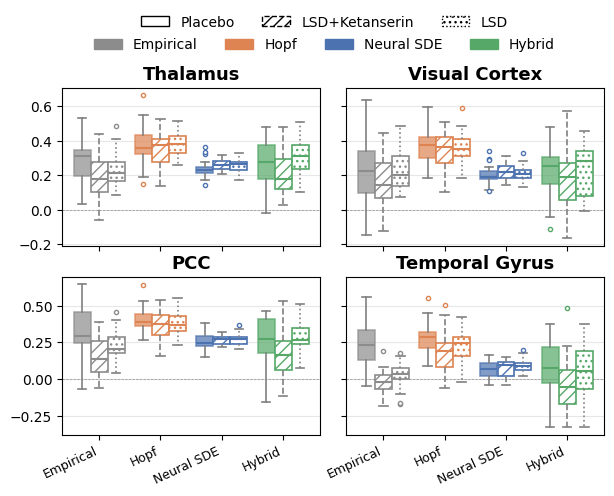

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# 1. Map Colors to Models
FC_MODEL_COLORS = {
    "Empirical": "#8C8C8C",   # gray (baseline/target)
    "Hopf": "#DD8452",        # salmon
    "Neural SDE": "#4C72B0",  # blue
    "GNN Hopf": "#55A868",    # green
    "Hybrid": "#55A868",      # green
}

# 2. Map Shapes/Patterns to Conditions
CONDITION_HATCHES = {
    ctrl_vals[0]: "",      # Plain (solid fill)
    ctrl_vals[1]: "///",   # Dashed/Slanted stripes
    ctrl_vals[2]: "...",   # Dotted pattern
}

CONDITION_LINESTYLES = {
    ctrl_vals[0]: "-",     # Plain line
    ctrl_vals[1]: "--",    # Dashed line
    ctrl_vals[2]: ":",     # Dotted line
}

model_names = ['Empirical', 'Hopf', 'Neural SDE', 'GNN Hopf']
model_names2 = ['Empirical', 'Hopf', 'Neural SDE', 'Hybrid']

ctrl_vals = sorted(CONDITION_LABELS.keys())
n_models = len(model_names)
n_conds = len(ctrl_vals)

# Box positions: group by model, sub-group by condition
box_width = 0.25
group_width = n_conds * box_width + 0.15  # spacing between model groups

# CHANGE 1: Added sharey='row' to share the y-axis and remove inner ticks
fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharey='row', gridspec_kw={'wspace': 0.1})
axes = axes.flatten()

for roi_idx in range(n_rois):
    ax = axes[roi_idx]
    all_bp = []

    for mi, mname in enumerate(model_names):
        group_center = mi * group_width
        
        # Color is now based on the MODEL
        model_color = FC_MODEL_COLORS[mname] 
        
        for ci, cv in enumerate(ctrl_vals):
            data = fc_data[mname].get(cv)
            if data is None:
                continue
            values = data[:, roi_idx]
            
            pos = group_center + (ci - 1) * box_width

            # Define facecolor and alpha based on whether it is the plain condition
            is_plain = (cv == ctrl_vals[0])
            box_facecolor = model_color if is_plain else "white"
            box_alpha = 0.7 if is_plain else 1.0

            bp = ax.boxplot(
                values, positions=[pos], widths=box_width * 0.99,
                patch_artist=True, manage_ticks=False,
                zorder=3,
                boxprops=dict(
                    facecolor=box_facecolor, 
                    alpha=box_alpha, 
                    edgecolor=model_color,         # Box edges and hatch color
                    linestyle=CONDITION_LINESTYLES[cv], 
                    linewidth=1.2,
                    hatch=CONDITION_HATCHES[cv]    # Apply shape/pattern
                ),
                # CHANGE 2: Set median line color to "grey"
                medianprops=dict(color=model_color, linewidth=1.5), 
                whiskerprops=dict(color="grey", linestyle=CONDITION_LINESTYLES[cv], linewidth=1.2), 
                capprops=dict(color="grey", linewidth=1.2), 
                flierprops=dict(
                    marker="o", 
                    markersize=3, 
                    markeredgecolor=model_color,   # Dot outlines
                    markerfacecolor="white",       # Dot background
                    alpha=1.0
                ),
            )
            all_bp.append(bp)

    # X-axis: model names at group centers
    ax.set_xticks([mi * group_width for mi in range(n_models)])
    if roi_idx > 1: 
        ax.set_xticklabels(model_names2, rotation=25, ha="right", fontsize=9)
    else:
        ax.set_xticklabels([])
        
    #if roi_idx % 2 == 0: 
    #    ax.set_ylabel("Mean FC", fontsize=10)
        
    ax.set_title(ROI_NAMES[roi_idx], fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", zorder=1)


# 3. Create Legends
# Legend A: Models (Colors)
model_patches = [
    mpatches.Patch(facecolor=FC_MODEL_COLORS[m], edgecolor=FC_MODEL_COLORS[m], alpha=1.0, label=m)
    for m in model_names2
]

# Legend B: Conditions (Shapes/Patterns)
cond_patches = [
    mpatches.Patch(
        facecolor="white", edgecolor="black", alpha=1.0,
        hatch=CONDITION_HATCHES[cv], linestyle=CONDITION_LINESTYLES[cv], 
        label=CONDITION_LABELS[cv]
    )
    for cv in ctrl_vals
]

# Add both legends to the top
fig.legend(handles=cond_patches, loc="upper center", ncol=n_conds, fontsize=10,
           bbox_to_anchor=(0.5, 1.07), frameon=False)

fig.legend(handles=model_patches, loc="upper center", ncol=n_models, fontsize=10,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout()

# Save logic
Path("paper/images/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images/lsd/fc_boxplots_by_region.pdf", bbox_inches="tight", dpi=150)

Path("paper/images_png/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_png/lsd/fc_boxplots_by_region.png", bbox_inches="tight", dpi=200)

Path("paper/images_svg/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_svg/lsd/fc_boxplots_by_region.svg", bbox_inches="tight")

plt.show()

## 5. Summary Table (Mean +/- Std)

In [12]:
import pandas as pd

rows = []
for mname in model_names:
    for cv in ctrl_vals:
        data = fc_data[mname].get(cv)
        if data is None:
            continue
        for roi_idx, roi_name in enumerate(ROI_NAMES):
            vals = data[:, roi_idx]
            rows.append({
                "Model": mname,
                "Condition": CONDITION_LABELS[cv],
                "Region": roi_name,
                "Mean FC": f"{vals.mean():.3f}",
                "Std FC": f"{vals.std():.3f}",
                "N": len(vals),
            })

df = pd.DataFrame(rows)
df

,Model,Condition,Region,Mean FC,Std FC,N
0,Empirical,Placebo,Thalamus,0.287,0.123,25
1,Empirical,Placebo,Visual Cortex,0.232,0.183,25
2,Empirical,Placebo,PCC,0.313,0.184,25
3,Empirical,Placebo,Temporal Gyrus,0.236,0.161,25
4,Empirical,LSD+Ketanserin,Thalamus,0.182,0.137,25
5,Empirical,LSD+Ketanserin,Visual Cortex,0.153,0.135,25
6,Empirical,LSD+Ketanserin,PCC,0.155,0.129,25
7,Empirical,LSD+Ketanserin,Temporal Gyrus,-0.019,0.080,25
8,Empirical,LSD,Thalamus,0.224,0.094,25
9,Empirical,LSD,Visual Cortex,0.230,0.121,25


## 6. Alternative: Conditions on X-axis, Models as Colors

In [13]:
%matplotlib inline

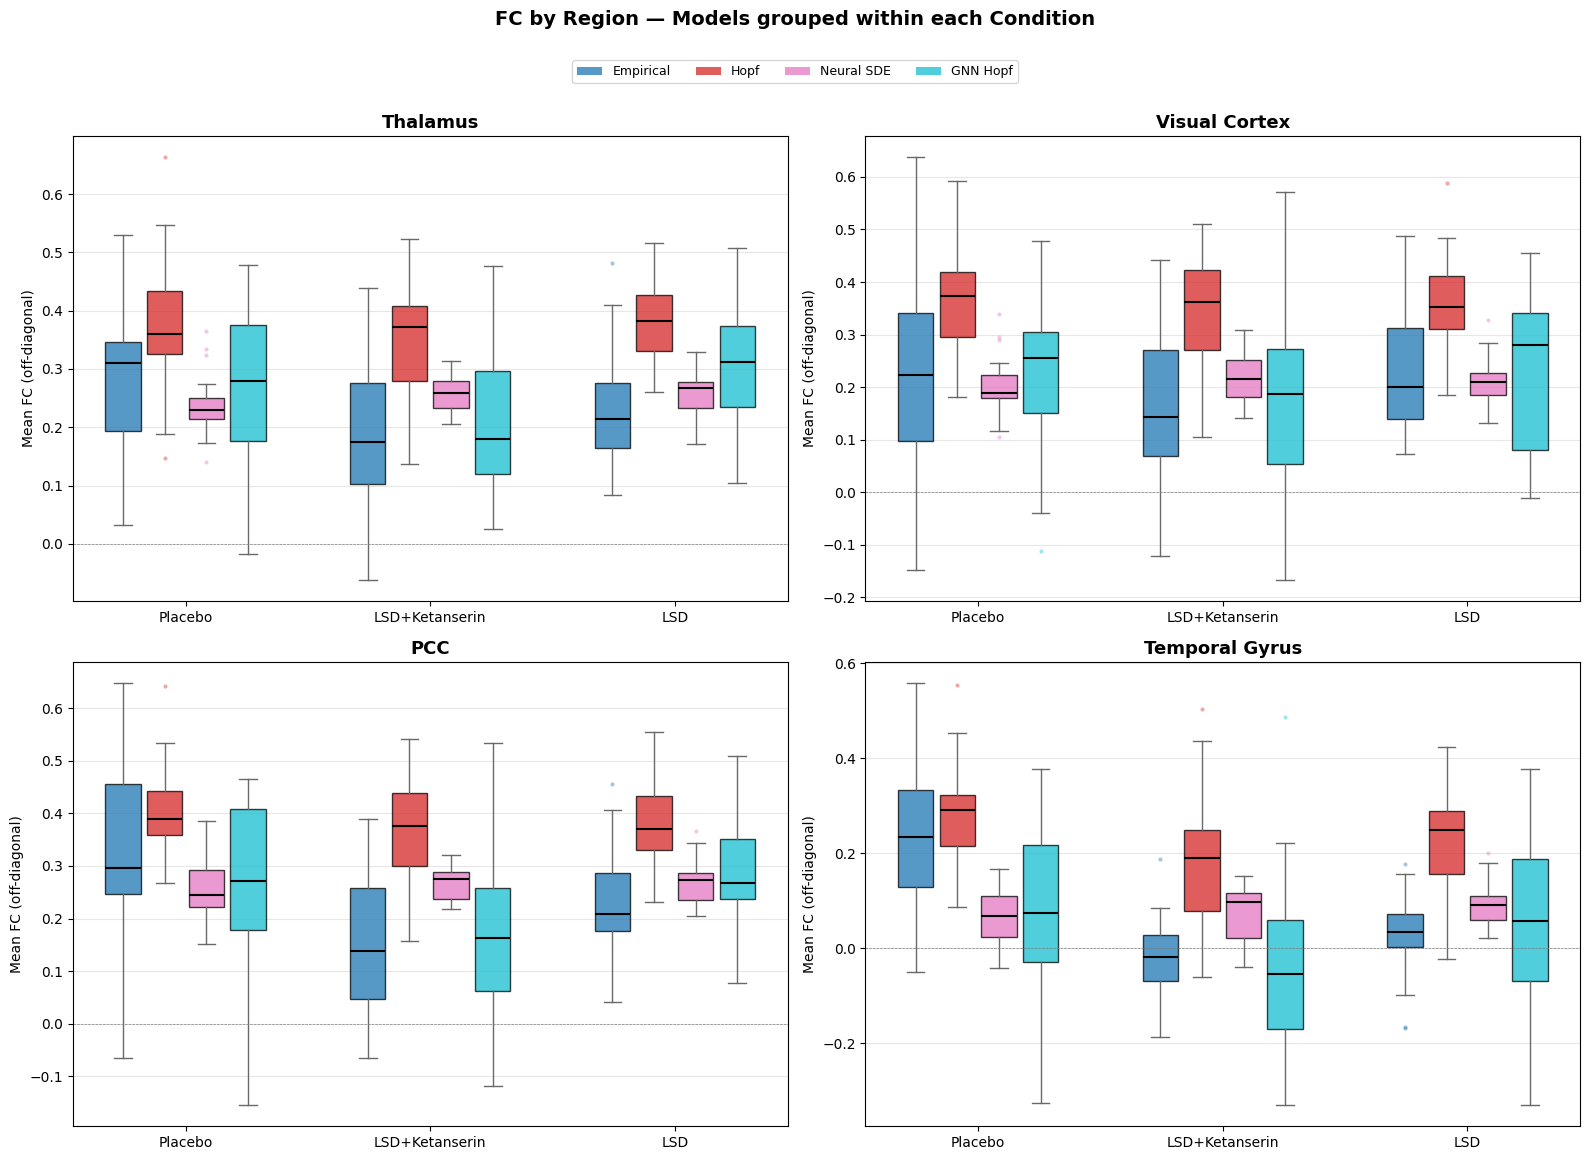

In [14]:
import matplotlib.cm as cm

# One color per model
model_colors = {
    name: cm.tab10(i / max(len(model_names) - 1, 1))
    for i, name in enumerate(model_names)
}

box_width = 0.08
group_width = len(model_names) * box_width + 0.15   # spacing between condition groups

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for roi_idx in range(n_rois):
    ax = axes[roi_idx]

    for ci, cv in enumerate(ctrl_vals):
        group_center = ci * group_width
        offset_start = -(len(model_names) - 1) / 2 * box_width

        for mi, mname in enumerate(model_names):
            data = fc_data[mname].get(cv)
            if data is None:
                continue
            values = data[:, roi_idx]
            pos = group_center + offset_start + mi * box_width
            color = model_colors[mname]

            ax.boxplot(
                values, positions=[pos], widths=box_width * 0.85,
                patch_artist=True, manage_ticks=False,
                boxprops=dict(facecolor=color, alpha=0.75),
                medianprops=dict(color="black", linewidth=1.5),
                whiskerprops=dict(color="dimgray"),
                capprops=dict(color="dimgray"),
                flierprops=dict(marker="o", markersize=3, alpha=0.4,
                                markerfacecolor=color, markeredgewidth=0),
            )

    # Condition names on x-axis
    ax.set_xticks([ci * group_width for ci in range(n_conds)])
    ax.set_xticklabels([CONDITION_LABELS[cv] for cv in ctrl_vals], fontsize=10)
    ax.set_ylabel("Mean FC (off-diagonal)", fontsize=10)
    ax.set_title(ROI_NAMES[roi_idx], fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Shared legend — one entry per model
legend_patches = [
    mpatches.Patch(facecolor=model_colors[mname], alpha=0.75, label=mname)
    for mname in model_names
]
fig.legend(handles=legend_patches, loc="upper center",
           ncol=min(len(model_names), 4), fontsize=9,
           bbox_to_anchor=(0.5, 1.01), frameon=True)

fig.suptitle("FC by Region — Models grouped within each Condition",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("paper/images/lsd/fc_boxplots_by_region_v2.pdf", bbox_inches="tight", dpi=150)
Path("paper/images_png/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_png/lsd/fc_boxplots_by_region_v2.png", bbox_inches="tight", dpi=200)
Path("paper/images_svg/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_svg/lsd/fc_boxplots_by_region_v2.svg", bbox_inches="tight")
plt.show()

## 7. Global Connectivity (Mean Upper-Triangle FC)

Replicates the global connectivity boxplot from `eda_lsd_builtin.ipynb` for the empirical data and a chosen subset of trained models (Hopf, Neural SDE, Hybrid). Per-subject global connectivity is the mean of the upper-triangular (off-diagonal) FC entries.

In [15]:
import seaborn as sns
import pandas as pd

GLOBAL_MODELS = ["Empirical", "Hopf", "Neural SDE", "Hybrid Hopf", "Hybrid+Neural"]
GLOBAL_MODELS = [m for m in GLOBAL_MODELS if m in fc_data]
print(f"Models for global connectivity: {GLOBAL_MODELS}")

triu_idx = np.triu_indices(n_rois, k=1)

def global_conn_per_subject(ts_tensor):
    """Mean upper-tri FC per subject from a (n_subj, n_rois, T) timeseries."""
    fc = compute_static_fc(ts_tensor).detach().cpu().numpy()
    if np.iscomplexobj(fc):
        fc = fc.real
    return fc[:, triu_idx[0], triu_idx[1]].mean(axis=-1)  # (n_subj,)

rows = []
for mname in GLOBAL_MODELS:
    for cv in ctrl_vals:
        ts = ts_sim[mname].get(cv)
        if ts is None:
            continue
        gc = global_conn_per_subject(ts)
        for v in gc:
            rows.append({
                "Model": mname,
                "Treatment": CONDITION_LABELS[cv],
                "Global Connectivity": float(v),
            })

df_global = pd.DataFrame(rows)
df_global.head()

Models for global connectivity: ['Empirical', 'Hopf', 'Neural SDE', 'Hybrid Hopf', 'Hybrid+Neural']


,Model,Treatment,Global Connectivity
0,Empirical,Placebo,0.394047
1,Empirical,Placebo,0.273862
2,Empirical,Placebo,0.350836
3,Empirical,Placebo,0.130546
4,Empirical,Placebo,0.394848


/tmp/ipykernel_402796/3211557289.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


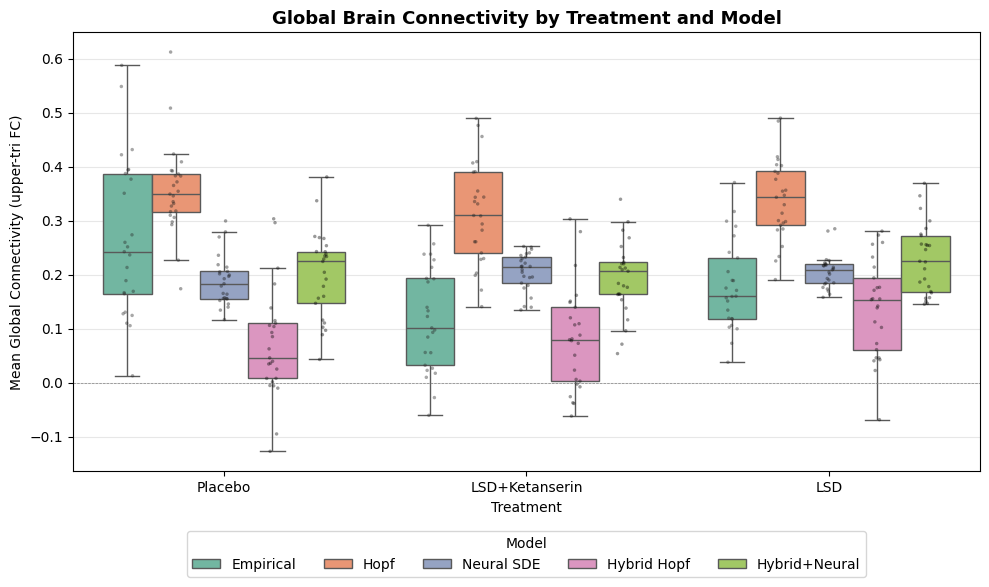

In [16]:
treatment_order = [CONDITION_LABELS[cv] for cv in ctrl_vals]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    x="Treatment", y="Global Connectivity", hue="Model",
    data=df_global, order=treatment_order, hue_order=GLOBAL_MODELS,
    palette="Set2", ax=ax, fliersize=0,
)
sns.stripplot(
    x="Treatment", y="Global Connectivity", hue="Model",
    data=df_global, order=treatment_order, hue_order=GLOBAL_MODELS,
    dodge=True, color="black", alpha=0.4, size=2.5, ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
n_m = len(GLOBAL_MODELS)
ax.legend(handles[:n_m], labels[:n_m], title="Model",
          loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=n_m, frameon=True)

ax.set_title("Global Brain Connectivity by Treatment and Model", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Global Connectivity (upper-tri FC)")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
Path("paper/images/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images/lsd/global_connectivity_boxplot.pdf", bbox_inches="tight", dpi=150)
Path("paper/images_png/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_png/lsd/global_connectivity_boxplot.png", bbox_inches="tight", dpi=200)
Path("paper/images_svg/lsd").mkdir(parents=True, exist_ok=True)
plt.savefig("paper/images_svg/lsd/global_connectivity_boxplot.svg", bbox_inches="tight")
plt.show()